# Diffusion U-Net on Oxford-IIIT Pet (TensorFlow)

TensorFlow/Keras port of the PyTorch noise-prediction notebook: trains a time-conditioned U-Net
to predict the noise added by the forward diffusion process on Oxford-IIIT Pet images, then
visualizes original vs. actual-noise vs. predicted-noise.

In [1]:
import math
import os

import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds


In [2]:
IMG_SIZE = 64          # resize pet images to 64x64 (keeps training fast)
BATCH_SIZE = 32
EPOCHS = 10             # bump this up for better results
LR = 2e-4
T = 1000                # number of diffusion timesteps
BASE_CH = 64            # base channel count for the U-Net
OUT_DIR = "./outputs"
os.makedirs(OUT_DIR, exist_ok=True)

tf.random.set_seed(0)


In [3]:
def normalize(x):
    return x * 2 - 1


## Data loading

In [4]:
def preprocess(example, img_size=IMG_SIZE, training=True):
    img = tf.cast(example["image"], tf.float32) / 255.0   # -> [0, 1]
    img = tf.image.resize(img, (img_size, img_size))
    if training:
        img = tf.image.random_flip_left_right(img)
    img = normalize(img)                                   # -> [-1, 1]
    return img

def get_dataset(batch_size=BATCH_SIZE, img_size=IMG_SIZE):
    ds = tfds.load("oxford_iiit_pet", split="train+test", as_supervised=False)
    ds = ds.map(lambda ex: preprocess(ex, img_size), num_parallel_calls=tf.data.AUTOTUNE)
    ds = (ds
          .shuffle(2000)
          .batch(batch_size, drop_remainder=True)
          .prefetch(tf.data.AUTOTUNE))
    return ds


## Model: sinusoidal time embedding + residual U-Net

In [5]:
class SinusoidalTimeEmbedding(tf.keras.layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def call(self, t):
        t = tf.cast(t, tf.float32)
        half_dim = self.dim // 2
        freq = math.log(10000) / (half_dim - 1)
        freq = tf.exp(tf.range(half_dim, dtype=tf.float32) * -freq)
        args = t[:, None] * freq[None, :]
        emb = tf.concat([tf.sin(args), tf.cos(args)], axis=-1)
        if self.dim % 2 == 1:  # zero-pad if odd
            emb = tf.pad(emb, [[0, 0], [0, 1]])
        return emb


class TimeMLP(tf.keras.layers.Layer):
    def __init__(self, dim, out_dim):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(dim)
        self.fc1 = tf.keras.layers.Dense(out_dim)
        self.fc2 = tf.keras.layers.Dense(out_dim)

    def call(self, t):
        x = self.time_embed(t)
        x = self.fc1(x)
        x = tf.nn.silu(x)
        x = self.fc2(x)
        return x


class ResBlock(tf.keras.layers.Layer):
    def __init__(self, out_ch, time_dim):
        super().__init__()
        self.norm1 = tf.keras.layers.GroupNormalization(groups=8)
        self.conv1 = tf.keras.layers.Conv2D(out_ch, 3, padding="same")

        self.time_proj = tf.keras.layers.Dense(out_ch)

        self.norm2 = tf.keras.layers.GroupNormalization(groups=8)
        self.conv2 = tf.keras.layers.Conv2D(out_ch, 3, padding="same")

        self.out_ch = out_ch
        self.skip = None  # built lazily once we know in_ch

    def build(self, input_shape):
        in_ch = input_shape[-1]
        self.skip = (tf.keras.layers.Conv2D(self.out_ch, 1)
                     if in_ch != self.out_ch else tf.keras.layers.Activation("linear"))

    def call(self, x, t_emb, training=False):
        h = self.conv1(tf.nn.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:, None, None, :]   # inject time info
        h = self.conv2(tf.nn.silu(self.norm2(h)))
        return h + self.skip(x)


class Down(tf.keras.layers.Layer):
    def __init__(self, out_ch, time_dim):
        super().__init__()
        self.block = ResBlock(out_ch, time_dim)
        self.pool = tf.keras.layers.Conv2D(out_ch, 4, strides=2, padding="same")

    def call(self, x, t_emb, training=False):
        h = self.block(x, t_emb, training=training)
        down = self.pool(h)
        return down, h


class Up(tf.keras.layers.Layer):
    def __init__(self, out_ch, time_dim):
        super().__init__()
        self.up = tf.keras.layers.Conv2DTranspose(out_ch, 4, strides=2, padding="same")
        # after concatenating with the skip connection, channels = out_ch + skip_ch
        self.block = ResBlock(out_ch, time_dim)

    def call(self, x, skip, t_emb, training=False):
        x = self.up(x)
        x = tf.concat([x, skip], axis=-1)
        return self.block(x, t_emb, training=training)


In [6]:
class SimpleUNet(tf.keras.Model):
    def __init__(self, in_ch=3, base_ch=BASE_CH, time_dim=256):
        super().__init__()
        self.time_mlp = TimeMLP(time_dim, time_dim)

        self.in_conv = tf.keras.layers.Conv2D(base_ch, 3, padding="same")

        self.down1 = Down(base_ch, time_dim)          # 64 -> 64
        self.down2 = Down(base_ch * 2, time_dim)       # 64 -> 128
        self.down3 = Down(base_ch * 4, time_dim)       # 128 -> 256

        self.bottleneck1 = ResBlock(base_ch * 4, time_dim)
        self.bottleneck2 = ResBlock(base_ch * 4, time_dim)

        self.up3 = Up(base_ch * 2, time_dim)  # 256 -> 128, skip=256
        self.up2 = Up(base_ch, time_dim)      # 128 -> 64,  skip=128
        self.up1 = Up(base_ch, time_dim)      # 64  -> 64,  skip=64

        self.out_norm = tf.keras.layers.GroupNormalization(groups=8)
        self.out_conv = tf.keras.layers.Conv2D(in_ch, 3, padding="same")

    def call(self, x, t, training=False):
        t_emb = self.time_mlp(t)

        h = self.in_conv(x)

        d1, skip1 = self.down1(h, t_emb, training=training)
        d2, skip2 = self.down2(d1, t_emb, training=training)
        d3, skip3 = self.down3(d2, t_emb, training=training)

        b = self.bottleneck1(d3, t_emb, training=training)
        b = self.bottleneck2(b, t_emb, training=training)

        u3 = self.up3(b, skip3, t_emb, training=training)
        u2 = self.up2(u3, skip2, t_emb, training=training)
        u1 = self.up1(u2, skip1, t_emb, training=training)

        out = self.out_conv(tf.nn.silu(self.out_norm(u1)))
        return out


## Diffusion forward process

In [7]:
class Diffusion:
    def __init__(self, timesteps=T, beta_start=1e-4, beta_end=0.02):
        self.T = timesteps
        self.betas = tf.cast(tf.linspace(beta_start, beta_end, timesteps), tf.float32)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = tf.math.cumprod(self.alphas, axis=0)
        self.sqrt_alphas_cumprod = tf.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = tf.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x0, t, noise=None):
        """Forward diffusion: sample x_t given x_0 and timestep t."""
        if noise is None:
            noise = tf.random.normal(tf.shape(x0))
        sqrt_ac = tf.reshape(tf.gather(self.sqrt_alphas_cumprod, t), (-1, 1, 1, 1))
        sqrt_1m_ac = tf.reshape(tf.gather(self.sqrt_one_minus_alphas_cumprod, t), (-1, 1, 1, 1))
        return sqrt_ac * x0 + sqrt_1m_ac * noise, noise


## Training loop

In [8]:
@tf.function
def train_step(model, optimizer, diffusion, images):
    batch_size = tf.shape(images)[0]
    # sample random timesteps for each image in the batch
    t = tf.random.uniform((batch_size,), 0, diffusion.T, dtype=tf.int32)

    with tf.GradientTape() as tape:
        # forward diffusion: add noise according to t
        x_t, noise = diffusion.q_sample(images, t)
        # predict the noise
        predicted_noise = model(x_t, t, training=True)
        loss = tf.reduce_mean(tf.square(predicted_noise - noise))

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss


def train(model, diffusion, dataset, epochs=EPOCHS, lr=LR):
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr)
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        n_batches = 0
        for images in dataset:
            loss = train_step(model, optimizer, diffusion, images)
            epoch_loss += float(loss)
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        print(f"Epoch [{epoch + 1}/{epochs}]  MSE Loss: {avg_loss:.4f}")

    return losses


In [9]:
def plot_loss(losses, out_path=os.path.join(OUT_DIR, "training_loss.png")):
    plt.figure(figsize=(7, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training Loss vs. Epoch")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    print(f"Saved loss curve to {out_path}")


## Visualize original / actual noise / predicted noise

In [10]:
def visualize_noise_predictions(model, diffusion, dataset,
                                 n_samples=4,
                                 out_path=os.path.join(OUT_DIR, "noise_predictions.png")):
    images = next(iter(dataset))[:n_samples]

    t = tf.random.uniform((n_samples,), 0, diffusion.T, dtype=tf.int32)
    x_t, noise = diffusion.q_sample(images, t)

    predicted_noise = model(x_t, t, training=False)

    def to_show(img_tensor):
        # noise / images are roughly in [-1, 1]; rescale to [0, 1] for display
        img = img_tensor.numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return img

    fig, axes = plt.subplots(3, n_samples, figsize=(3 * n_samples, 9))
    for i in range(n_samples):
        axes[0, i].imshow((images[i].numpy() + 1) / 2)
        axes[0, i].set_title(f"Original (t={int(t[i])})")
        axes[0, i].axis("off")

        axes[1, i].imshow(to_show(noise[i]))
        axes[1, i].set_title("Actual Noise")
        axes[1, i].axis("off")

        axes[2, i].imshow(to_show(predicted_noise[i]))
        axes[2, i].set_title("Predicted Noise")
        axes[2, i].axis("off")

    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    print(f"Saved noise visualization to {out_path}")


## Run everything

In [11]:
dataset = get_dataset()


c:\Users\Reaper\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...:  50%|█████     | 1/2 [00:49<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [00:50<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [00:51<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [00:52<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [00:53<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [00:54<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [00:55<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [00:56<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [00:57<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [00:58<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [00:59<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [01:00<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [01:01<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/2 [01:02<00:08,  8.55s/ url]

Dl Completed...:  50%|█████     | 1/

Dataset oxford_iiit_pet downloaded and prepared to C:\Users\Reaper\tensorflow_datasets\oxford_iiit_pet\4.0.0. Subsequent calls will reuse this data.


In [12]:
model = SimpleUNet()
diffusion = Diffusion()


Epoch [1/10]  MSE Loss: 0.2206
Epoch [2/10]  MSE Loss: 0.0903
Epoch [3/10]  MSE Loss: 0.0745
Epoch [4/10]  MSE Loss: 0.0659
Epoch [5/10]  MSE Loss: 0.0664
Epoch [6/10]  MSE Loss: 0.0611
Epoch [7/10]  MSE Loss: 0.0566
Epoch [8/10]  MSE Loss: 0.0552
Epoch [9/10]  MSE Loss: 0.0552
Epoch [10/10]  MSE Loss: 0.0526


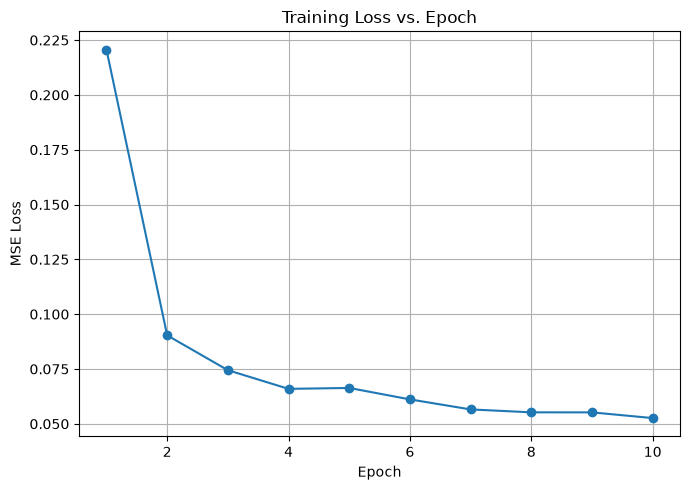

Saved loss curve to ./outputs\training_loss.png


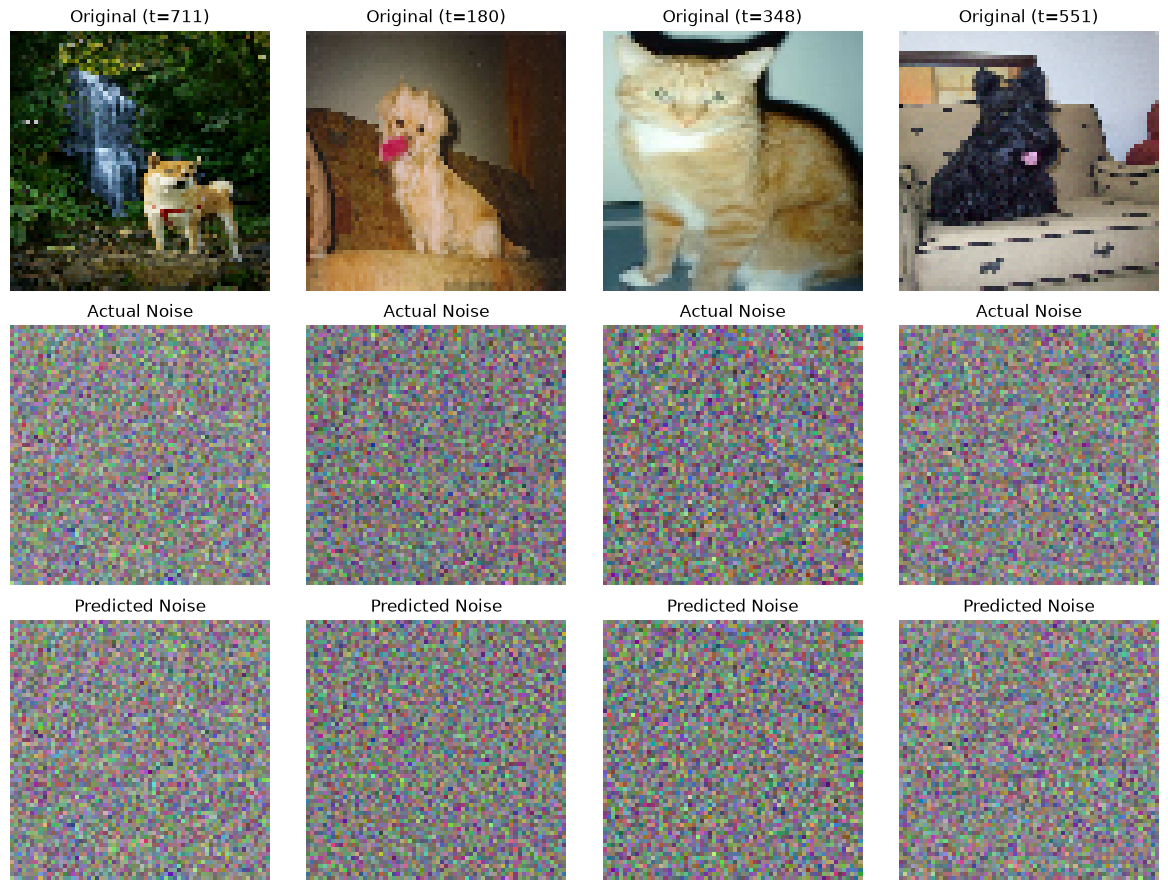

Saved noise visualization to ./outputs\noise_predictions.png


In [13]:
losses = train(model, diffusion, dataset)
plot_loss(losses)
visualize_noise_predictions(model, diffusion, dataset)


In [14]:
model.save_weights(os.path.join(OUT_DIR, "unet_diffusion_pets.weights.h5"))
